# Process SHAPE-MaP data

Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq
import subprocess

Read in reactivity scores from each experiment

In [2]:
# Read in sheet 2 from excel file
df = pd.read_excel('../data/dadonaite_2019/41564_2019_513_MOESM3_ESM.xlsx', sheet_name=2)

# Add a column giving the site on the negative strand
df['site_neg_strand'] = df.index + 1
sites = df['site_neg_strand'].values
df.set_index('site_neg_strand', inplace=True)

# Transpose dataframe and then add columns giving metadata
df = (
    df
    .T
    .reset_index()
    .rename(columns={'index':'experiment'})
)

def parse_metadata(experiment):
    experiment = experiment.replace('Puerto Rico', 'Puerto_Rico')
    parts = experiment.split()
    if len(parts) == 4:
        (strain, segment, substrate, replicate) = parts
    elif len(parts) == 3:
        (strain, segment, substrate) = parts
        replicate = 1
    elif len(parts) == 2:
        (strain, segment) = parts
        segment = segment[1:-1]
        substrate = 'vRNP'
        replicate = 1
    else:
        raise ValueError(f"Unexpected experiment format: {experiment}")
    if segment == 'M':
        segment = 'MP'
    return (strain, segment, substrate, replicate)

df['strain'], df['segment'], df['substrate'], df['replicate'] = zip(*df['experiment'].map(parse_metadata))

# Make a long-form dataframe with data averaged across replicates. Drop sites with missing data.
id_vars = ['experiment', 'strain', 'segment', 'substrate', 'replicate']
groupby_cols = ['strain', 'segment', 'substrate', 'site_neg_strand']
reactivity_df = (
    pd.melt(df, id_vars=id_vars, value_name='reactivity')
    .query('reactivity.notnull()')
    .query('reactivity > -998')
    .groupby(groupby_cols, as_index=False)['reactivity'].mean()
)
reactivity_df

/home/hhaddox/miniforge3/envs/flu-syn-rates/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,strain,segment,substrate,site_neg_strand,reactivity
0,A/Puerto_Rico/8/1934,HA,vRNP,22,0.311391
1,A/Puerto_Rico/8/1934,HA,vRNP,23,-1.338885
2,A/Puerto_Rico/8/1934,HA,vRNP,24,0.305128
3,A/Puerto_Rico/8/1934,HA,vRNP,25,0.361919
4,A/Puerto_Rico/8/1934,HA,vRNP,26,0.893081
...,...,...,...,...,...
67169,A/WSN/1933(H1N1),PB2,vRNP,2325,1.972969
67170,A/WSN/1933(H1N1),PB2,vRNP,2328,0.349404
67171,A/WSN/1933(H1N1),PB2,vRNP,2329,0.541242
67172,A/WSN/1933(H1N1),PB2,vRNP,2334,0.116441


Read in sequences

In [3]:
# Read in the sequences used in the experiments
seq_df = pd.read_excel('../data/dadonaite_2019/41564_2019_513_MOESM3_ESM.xlsx', sheet_name=1)
seq_df.rename(columns = {
    'Source Name' : 'experiment',
    'Characteristics[Nucleotide Sequence]' : 'sequence'
}, inplace=True)
seq_df = seq_df.dropna(subset=['experiment', 'sequence'])[['experiment', 'sequence']]

# Parse metadata
seq_df['strain'], seq_df['segment'], seq_df['substrate'], seq_df['replicate'] = zip(*seq_df['experiment'].map(parse_metadata))

# Get sequences for each strain and segment, ensuring that there is only one sequence per strain and segment
seq_df = (
    seq_df[['strain', 'segment', 'sequence']]
    .drop_duplicates()
)
assert(seq_df.duplicated(['strain', 'segment']).sum() == 0)

# Remove \n from sequences
seq_df['sequence'] = seq_df['sequence'].str.replace('\n', '')

# Add columns with sequence lengths and reverse complement sequences
seq_df['seq_len'] = seq_df['sequence'].apply(len)
seq_df['sequence_rc'] = seq_df['sequence'].apply(lambda s: str(Seq(s).reverse_complement()))

seq_df

/home/hhaddox/miniforge3/envs/flu-syn-rates/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,strain,segment,sequence,seq_len,sequence_rc
0,A/WSN/1933(H1N1),PB2,AGTAGAAACAAGGTCGTTTTTAAACTATTCGACACTAATTGATGGC...,2341,AGCGAAAGCAGGTCAATTATATTCAATATGGAAAGAATAAAAGAAC...
6,A/WSN/1933(H1N1),PB1,AGTAGAAACAAGGCATTTTTTCATGAAGGACAAGCTAAATTCACTA...,2341,AGCGAAAGCAGGCAAACCATTTGAATGGATGTCAATCCGACTTTAC...
12,A/WSN/1933(H1N1),PA,AGTAGAAACAAGGTACTTTTTTGGACAGTATGGATAGCAAATAGTA...,2233,AGCGAAAGCAGGTACTGATTCAAAATGGAAGATTTTGTGCGACAAT...
18,A/WSN/1933(H1N1),HA,AGTAGAAACAAGGGTGTTTTTCCTTATATTTCTGAAATCCTAATCT...,1775,AGCAAAAGCAGGGGAAAATAAAAACAACCAAAATGAAGGCttttgT...
24,A/WSN/1933(H1N1),NP,AGTAGAAACAAGGGTATTTTTCTTTAATTGTCGTACTCCTCTGCAT...,1565,AGCAAAAGCAGGGTAGATAATCACTCACAGAGTGACATCGAAATCA...
30,A/WSN/1933(H1N1),NA,AGTAGAAACAAGGAGTTTTTTGAACAAACTACTTGTCAATGGTGAA...,1409,AGCAAAAGCAGGAGTTTAAATGAATCCAAACCAGAAAATAATAACC...
36,A/WSN/1933(H1N1),MP,AGTAGAAACAAGGTAGTTTTTTACTCCAGCTCTATGTTGACAAAAT...,1027,AGCGAAAGCAGGTAGATATTGAAAGATGAGTCTTCTAACCGAGGTC...
42,A/WSN/1933(H1N1),NS,AGTAGAAACAAGGGTGTTTTTTATTATTAAATAAGCTGAAACGAGA...,890,AGCAAAAGCAGGGTGACAAAGACATAATGGATCCAAACACTGTGTC...
48,A/Puerto_Rico/8/1934,PB2,AGTAGAAACAAGGTCGTTTTTAAACTATTCGACACTAATTGATGGC...,2341,AGCGAAAGCAGGTCAATTATATTCAATATGGAAAGAATAAAAGAAC...
49,A/Puerto_Rico/8/1934,PB1,AGTAGAAACAAGGCATTTTTTCATGAAGGACAAGCTAAATTCACTA...,2341,AGCGAAAGCAGGCAAACCATTTGAATGGATGTCAATCCGACCTTAC...


For each segment, write a FASTA file with the sequences from each experiment and the reference sequence used to build trees. Then align the sequences.

In [4]:
aligned_seqs_dict = defaultdict(list)
for (segment, data) in seq_df.groupby('segment'):

    # Skip HA and NA segments
    if segment in ['HA', 'NA']:
        continue

    print(segment)

    # Read in reference sequence and update its record ID to be reference
    ref_fasta = f'../../flu-usher/results/{segment}/all/curated_reference.fasta'
    ref_record = next(SeqIO.parse(ref_fasta, 'fasta'))
    ref_record.id = 'reference'
    ref_record.description = ''

    # Write a FASTA file with the reference sequence and all sequences for this segment
    records = [ref_record]
    for (_, row) in data.iterrows():
        record = SeqIO.SeqRecord(Seq(row['sequence_rc']), id=row['strain'], description='')
        records.append(record)
    output_dir = f'../results/shapemap/'
    if not os.path.isdir(output_dir):
        os.makedirs(output_dir)
    unaligned_fasta = f'{output_dir}/{segment}_unaligned.fasta'
    if not os.path.isfile(unaligned_fasta):
        with open(unaligned_fasta, 'w') as output_handle:
            SeqIO.write(records, output_handle, 'fasta')

    # Align the sequences using MUSCLE
    aligned_fasta = f'{output_dir}/{segment}_aligned.fasta'
    if not os.path.isfile(aligned_fasta):
        cmd = ['muscle', '-align', unaligned_fasta, '-output', aligned_fasta]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)

    # Read in the aligned sequences
    aligned_records = list(SeqIO.parse(aligned_fasta, 'fasta'))
    for record in aligned_records:
        aligned_seqs_dict['segment'].append(segment)
        aligned_seqs_dict['strain'].append(record.id)
        aligned_seqs_dict['sequence'].append(str(record.seq))

aligned_seqs_df = pd.DataFrame(aligned_seqs_dict)

MP
NP
NS
PA
PB1
PB2


Read in alignments, record numbering information relative to reference, and plot percent identities between sequences.

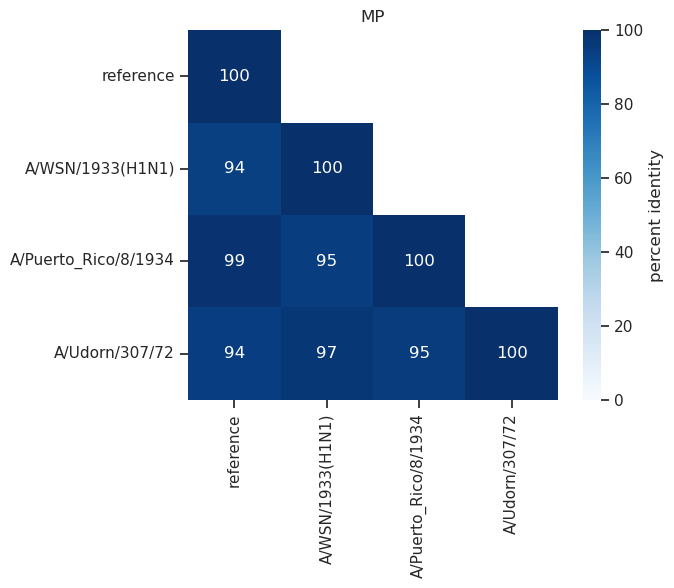

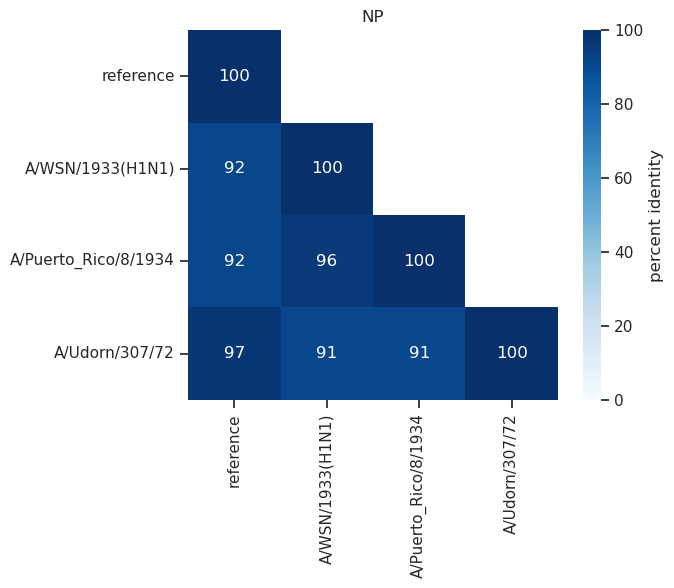

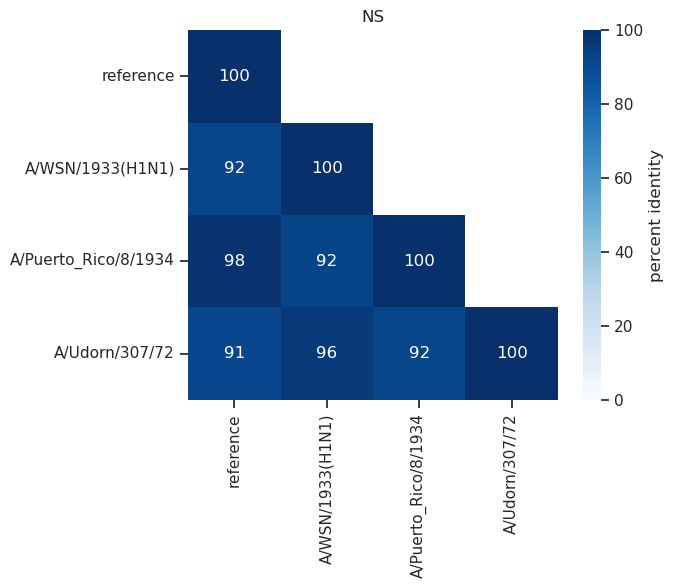

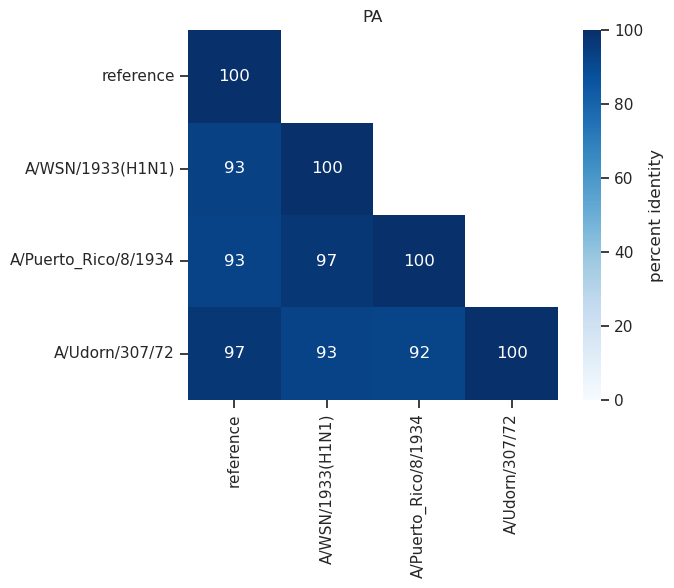

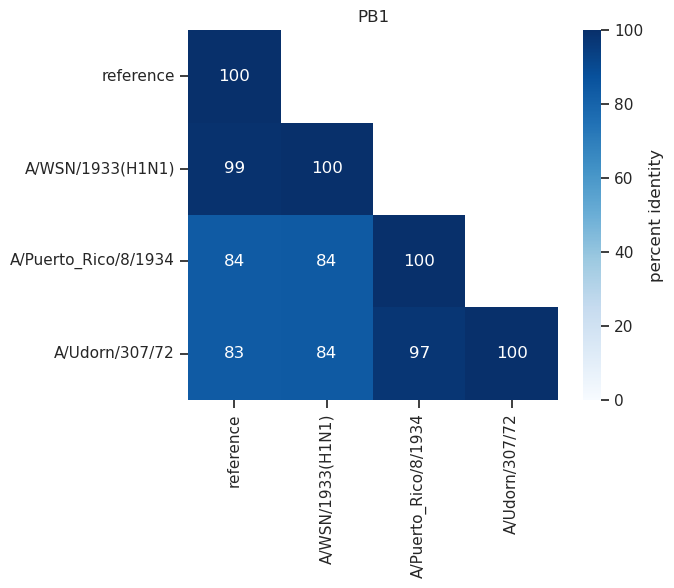

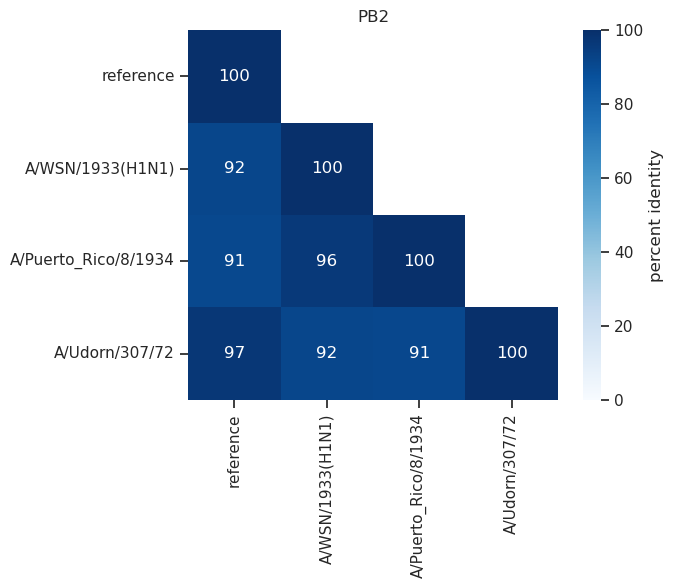

In [5]:
# Compute a pairwise identity matrix
def compute_pairwise_identity(seqs):
    n = len(seqs)
    identity_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            n_sites_to_compare = 0
            n_identical_sites = 0
            for (a, b) in zip(seqs[i], seqs[j]):
                if a != '-' and b != '-':
                    n_sites_to_compare += 1
                    if a == b:
                        n_identical_sites += 1
            assert n_sites_to_compare > 0, f"No sites to compare between {records[i].id} and {records[j].id}"            
            identity = n_identical_sites / n_sites_to_compare * 100
            identity_matrix[i, j] = identity
            identity_matrix[j, i] = identity

    return pd.DataFrame(identity_matrix, index=[record.id for record in records], columns=[record.id for record in records])

# Iterate over segments, then record numbering information
numbering_dict = defaultdict(list)
for (segment, data) in aligned_seqs_df.groupby('segment'):
    
    # Iterate over sequences for a given segment
    alignment_length = len(data.iloc[0]['sequence'])
    seqs = []
    for (i, row) in data.iterrows():
        seq = row['sequence']
        assert len(seq) == alignment_length, f"Sequence length mismatch for segment {segment}, strain {row['strain']}"
        seqs.append(seq)

        # Iterate over sites and record alignment index vs. non-gap nucleotide index        
        seq_index = 1
        for alignment_index in range(1, alignment_length + 1):
            wt_nt = seq[alignment_index - 1]
            if wt_nt != '-':
                numbering_dict['strain'].append(row['strain'])
                numbering_dict['segment'].append(segment)
                numbering_dict['alignment_index'].append(alignment_index)
                numbering_dict['site_pos_strand'].append(seq_index)
                numbering_dict['wt_nt_pos_strand'].append(wt_nt)
                seq_index += 1

    # Plot a pairwise identity matrix
    df = compute_pairwise_identity(seqs)
    mask = np.triu(np.ones_like(df, dtype=bool), k=1)
    sns.heatmap(
        df, cmap='Blues', annot=True, fmt='.0f', square=True, mask=mask,
        vmin=0, vmax=100, cbar_kws={'label': 'percent identity'}
    )
    plt.title(segment)
    plt.show()

# Create a dataframe with numbering information
numbering_df = pd.DataFrame(numbering_dict)

# Get reference numbering information
ref_numbering_df = (
    numbering_df[numbering_df['strain'] == 'reference']
    [['segment', 'alignment_index', 'site_pos_strand', 'wt_nt_pos_strand']]
    .rename(columns={'site_pos_strand':'ref_site', 'wt_nt_pos_strand':'ref_wt_nt'})
)

# Merge reference numbering into numbering data for other strains
numbering_df = numbering_df.merge(ref_numbering_df, on=['segment', 'alignment_index'])

Add sequence and numbering information to the dataframe with reactivities.

In [8]:
# Make a dataframe with one row per site in each experiment, giving the nucleotide at that site,
# as well as the corresponding site number and nucleotide on the positive strand
seq_dict = defaultdict(list)
for (i, row) in seq_df.iterrows():
    seq_len = len(row['sequence'])
    for (n, nt) in enumerate(row['sequence'], 1):
        seq_dict['strain'].append(row['strain'])
        seq_dict['segment'].append(row['segment'])
        seq_dict['site_neg_strand'].append(n)
        seq_dict['wt_nt_neg_strand'].append(nt)
        seq_dict['site_pos_strand'].append(seq_len - n + 1)
        seq_dict['wt_nt_pos_strand'].append(str(Seq(nt).reverse_complement()))
per_site_seq_df = pd.DataFrame(seq_dict)

# Merge the sequence/numbering dataframe into the reactivity dataframe
cols = ['strain', 'segment', 'substrate', 'ref_site', 'ref_wt_nt', 'site_pos_strand', 'wt_nt_pos_strand', 'reactivity']
all_data = (
    reactivity_df
    .merge(pd.DataFrame(seq_dict), on=['strain', 'segment', 'site_neg_strand'])
    .merge(numbering_df, on=['strain', 'segment', 'site_pos_strand', 'wt_nt_pos_strand'])
    [cols]
)

# Save the final dataframe
all_data.to_csv('../results/shapemap/all_data.csv', index=False)

all_data

,strain,segment,substrate,ref_site,ref_wt_nt,site_pos_strand,wt_nt_pos_strand,reactivity
0,A/Puerto_Rico/8/1934,MP,vRNP,981,A,1006,A,0.135522
1,A/Puerto_Rico/8/1934,MP,vRNP,980,T,1005,T,-0.047599
2,A/Puerto_Rico/8/1934,MP,vRNP,979,G,1004,G,0.219393
3,A/Puerto_Rico/8/1934,MP,vRNP,978,A,1003,A,-1.099986
4,A/Puerto_Rico/8/1934,MP,vRNP,977,G,1002,G,-3.755355
...,...,...,...,...,...,...,...,...
50004,A/WSN/1933(H1N1),PB2,vRNP,5,A,32,A,0.227574
50005,A/WSN/1933(H1N1),PB2,vRNP,4,G,31,G,0.451602
50006,A/WSN/1933(H1N1),PB2,vRNP,3,G,30,G,0.772861
50007,A/WSN/1933(H1N1),PB2,vRNP,2,T,29,T,6.374651


In [ ]:
# Read in sheet 2 from excel file
df = pd.read_excel('../data/dadonaite_2019/41564_2019_513_MOESM3_ESM.xlsx', sheet_name=2)

# Add a column giving the site on the negative strand
df['site_neg_strand'] = df.index + 1
sites = df['site_neg_strand'].values
df.set_index('site_neg_strand', inplace=True)

# Transpose dataframe and then add columns giving metadata
df = (
    df
    .T
    .reset_index()
    .rename(columns={'index':'experiment'})
    .query('experiment.str.contains("A/WSN/")')
)

def parse_metadata(experiment):
    parts = experiment.split()
    if len(parts) == 4:
        (strain, segment, substrate, replicate) = parts
    elif len(parts) == 3:
        (strain, segment, substrate) = parts
        replicate = 1
    else:
        raise ValueError(f"Unexpected experiment format: {experiment}")
    return (strain, segment, substrate, replicate)

df['strain'], df['segment'], df['substrate'], df['replicate'] = zip(*df['experiment'].map(parse_metadata))

# Make a long-form dataframe with data averaged across replicates
id_vars = ['experiment', 'strain', 'segment', 'substrate', 'replicate']
reactivity_df = (
    pd.melt(df, id_vars=id_vars, value_name='reactivity')
    .query('reactivity.notnull()')
)

# Read in the sequences used in the experiments
seq_df = pd.read_excel('../data/dadonaite_2019/41564_2019_513_MOESM3_ESM.xlsx', sheet_name=1)
seq_df.rename(columns = {
    'Source Name' : 'experiment',
    'Characteristics[Nucleotide Sequence]' : 'sequence'
}, inplace=True)
seq_df = seq_df.dropna(subset=['experiment', 'sequence'])[['experiment', 'sequence']]

# Convert dataframe to a dictionary mapping experiment to sequence
assert seq_df['experiment'].is_unique, "Experiments are not unique in sequence dataframe"
full_seq_dict = dict(zip(seq_df['experiment'], seq_df['sequence']))

# Make a dataframe with one row per site in each experiment, giving the nucleotide at that site,
# as well as the corresponding site number and nucleotide on the positive strand
seq_dict = defaultdict(list)
for (i, row) in seq_df.iterrows():
    seq_len = len(row['sequence'])
    for (n, nt) in enumerate(row['sequence'], 1):
        seq_dict['experiment'].append(row['experiment'])
        seq_dict['site_neg_strand'].append(n)
        seq_dict['wt_nt_neg_strand'].append(nt)
        seq_dict['site_pos_strand'].append(seq_len - n + 1)
        seq_dict['wt_nt_pos_strand'].append(str(Seq(nt).reverse_complement()))

# Merge the sequence/numbering dataframe into the reactivity dataframe
reactivity_df = reactivity_df.merge(pd.DataFrame(seq_dict), on=['experiment', 'site_neg_strand'])

# Average reactivities across replicates and drop rows with missing data
groupby_cols = [
    'strain', 'segment', 'substrate', 'site_neg_strand', 'wt_nt_neg_strand',
    'site_pos_strand', 'wt_nt_pos_strand',
]
pivot_index_cols = groupby_cols.copy()
pivot_index_cols.remove('substrate')
reactivity_df = (
    reactivity_df
    .query('reactivity > -998')
    .groupby(groupby_cols, as_index=False)['reactivity'].mean()
    .pivot_table(index=pivot_index_cols, columns='substrate', values='reactivity')
    .rename(columns={col: f'reactivity_{col}' for col in reactivity_df['substrate'].unique()})
    .reset_index()
    .rename_axis(columns=None)
    .rename(columns={'site_pos_strand':'site', 'wt_nt_pos_strand':'wt_nt_exp'})
)

reactivity_df.head()